This notebook generates Figure 7 in the manuscript.

In [1]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import pickle as pkl
import skimage
import yaml
from typing import Union, Optional, Type, Tuple, List, Dict
import sys
from skimage.color import label2rgb
import json
# import nrrd

import pandas as pd
import seaborn as sns
# Project Root
# used for searching packages and functions
# TODO: enter your project root dir here
ROOT_DIR = '/project/Xie_Lab/zgu/xiao_multiplex/multiTAP/image_cytof'

sys.path.append(ROOT_DIR)
sys.path.append(os.path.join(ROOT_DIR, 'image_cytof'))
from cytof.hyperion_preprocess import cytof_read_data_roi
from cytof.utils import save_multi_channel_img, check_feature_distribution
from cytof.classes import CytofImageTiff
from cytof.classes import CytofCohort


/project/Xie_Lab/zgu/conda_stuff/envs/cytof-shared/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# to generate aggregate file, see cell_type_assignments.ipynb TODO: generate that from cell_spatial_survival.ipynb
# read in aggregate file
BASE_CSV_DIR = "/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work"
roi_cell_types_wide = pd.read_csv(os.path.join(BASE_CSV_DIR, "nontumor_cell_counts_per_roi_aggregate.csv"))

# define CAF columns
caf_cols = ["pt_id", "mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]
roi_CAF_only_wide = roi_cell_types_wide[caf_cols]

roi_CAF_only_wide["CAF_total"] = roi_CAF_only_wide[caf_cols].sum(axis=1)
# pt_CAF_only_wide = pt_CAF_only_wide[pt_CAF_only_wide["CAF_total"]>20].reset_index(drop=True)

# # add within pt counts
pt_caf_summary = (
    roi_CAF_only_wide
    .groupby("pt_id")[caf_cols].sum()  # sum CAF counts across ROIs
    .assign(CAF_total=lambda x: x.sum(axis=1))  # total CAFs
    .reset_index()
)

# some pt have very few CAF values, remove them
pt_caf_counts = pt_caf_summary[pt_caf_summary['CAF_total']>20].reset_index(drop=True)
pt_caf_counts = pt_caf_counts.drop(columns="CAF_total")
pt_caf_counts = pt_caf_counts.set_index(keys='pt_id')
pt_caf_counts

/tmp/ipykernel_677107/733595507.py:10: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  roi_CAF_only_wide["CAF_total"] = roi_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_677107/733595507.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_CAF_only_wide["CAF_total"] = roi_CAF_only_wide[caf_cols].sum(axis=1)
/tmp/ipykernel_677107/733595507.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the funct

,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,11,2,4,106,0,5,7,20,5,4,997
175_10,47,39,32,1,0,9,45,10,24,9,225
175_100,23,0,3,18,3,42,34,2,2,243,113
175_101,26,29,12,13,2,124,9,47,0,56,85
175_102,1,57,20,1,0,63,68,168,4,174,72
...,...,...,...,...,...,...,...,...,...,...,...
88_534,9,1,1,2,0,4,41,34,9,72,59
88_535,0,0,0,5,0,0,8,1,10,1,6
88_536,18,0,13,0,0,1,174,20,1,79,48


In [3]:
# derive proportions per patient
pt_caf_props = pt_caf_counts.div(pt_caf_counts.sum(axis=1), axis=0)
pt_caf_props

,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
175_1,0.009475,0.001723,0.003445,0.091301,0.000000,0.004307,0.006029,0.017227,0.004307,0.003445,0.858742
175_10,0.106576,0.088435,0.072562,0.002268,0.000000,0.020408,0.102041,0.022676,0.054422,0.020408,0.510204
175_100,0.047619,0.000000,0.006211,0.037267,0.006211,0.086957,0.070393,0.004141,0.004141,0.503106,0.233954
175_101,0.064516,0.071960,0.029777,0.032258,0.004963,0.307692,0.022333,0.116625,0.000000,0.138958,0.210918
175_102,0.001592,0.090764,0.031847,0.001592,0.000000,0.100318,0.108280,0.267516,0.006369,0.277070,0.114650
...,...,...,...,...,...,...,...,...,...,...,...
88_534,0.038793,0.004310,0.004310,0.008621,0.000000,0.017241,0.176724,0.146552,0.038793,0.310345,0.254310
88_535,0.000000,0.000000,0.000000,0.161290,0.000000,0.000000,0.258065,0.032258,0.322581,0.032258,0.193548
88_536,0.050847,0.000000,0.036723,0.000000,0.000000,0.002825,0.491525,0.056497,0.002825,0.223164,0.135593


In [4]:
# perform hierechical clustering
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

caf_cols_plotting = ["mCAF", "iCAF", "tCAF", "hypoxic CAF", "hypoxic tCAF", "IFN CAF", "vCAF", "dCAF", "PDPN CAF", "Collagen CAF", "SMA CAF"]

# --- Clustering patients on proportions ---
Z = linkage(pt_caf_props, method="ward")         # hierarchical clustering
clusters = fcluster(Z, t=4, criterion="maxclust")  # assign 4 meta-clusters

# --- Reorder patients by clustering ---
dendro = dendrogram(Z, labels=pt_caf_props.index, no_plot=True)
ordered_idx = dendro["ivl"]

# reorder everything
pt_caf_props_ordered = pt_caf_props.loc[ordered_idx]
pt_caf_counts_oredered = pt_caf_counts.loc[ordered_idx]
pt_cluster_ordered = pd.Series(clusters, index=pt_caf_props.index).loc[ordered_idx]

# map clusters to colors
cluster_palette = {1:"red", 2:"blue", 3:"green", 4:"purple"}
cluster_colors = pd.Series(clusters, index=pt_caf_props.index).map(cluster_palette)
cluster_colors = cluster_colors.loc[ordered_idx]
cluster_colors

pt_id
176_306       red
88_443        red
175_8         red
178_490       red
175_174       red
            ...  
87_219     purple
175_93     purple
87_247     purple
178_521    purple
87_195     purple
Length: 1053, dtype: object

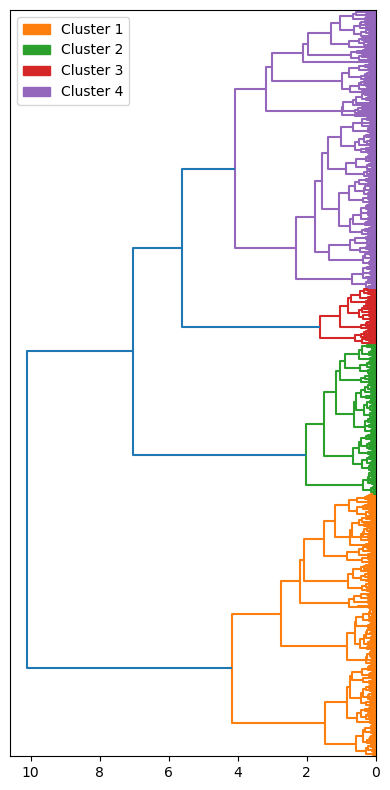

In [6]:
%matplotlib inline
import matplotlib.patches as mpatches

plt.figure(figsize=(4,8))

# dendrogram on the left
ddata = dendrogram(
    Z,
    orientation="left",
    color_threshold=Z[-(4-1), 2],  # ensures 4 cluster colors
    no_labels=True
)

# map leaf labels to cluster IDs
leaf_labels = ddata['ivl']
leaf_clusters = {leaf: clusters[int(leaf)] for leaf in leaf_labels}

# map cluster IDs to the *leaf colors*
cluster_colors = {}
for leaf, color in zip(ddata['ivl'], ddata['leaves_color_list']):
    cid = leaf_clusters[leaf]
    if cid not in cluster_colors:  # assign first color seen for that cluster
        cluster_colors[cid] = color

# build legend patches with consistent colors
patches = [
    mpatches.Patch(color=cluster_colors[cid], label=f"Cluster {cid}")
    for cid in sorted(cluster_colors)
]

plt.legend(handles=patches, loc="upper left")
plt.tight_layout()
plt.show()

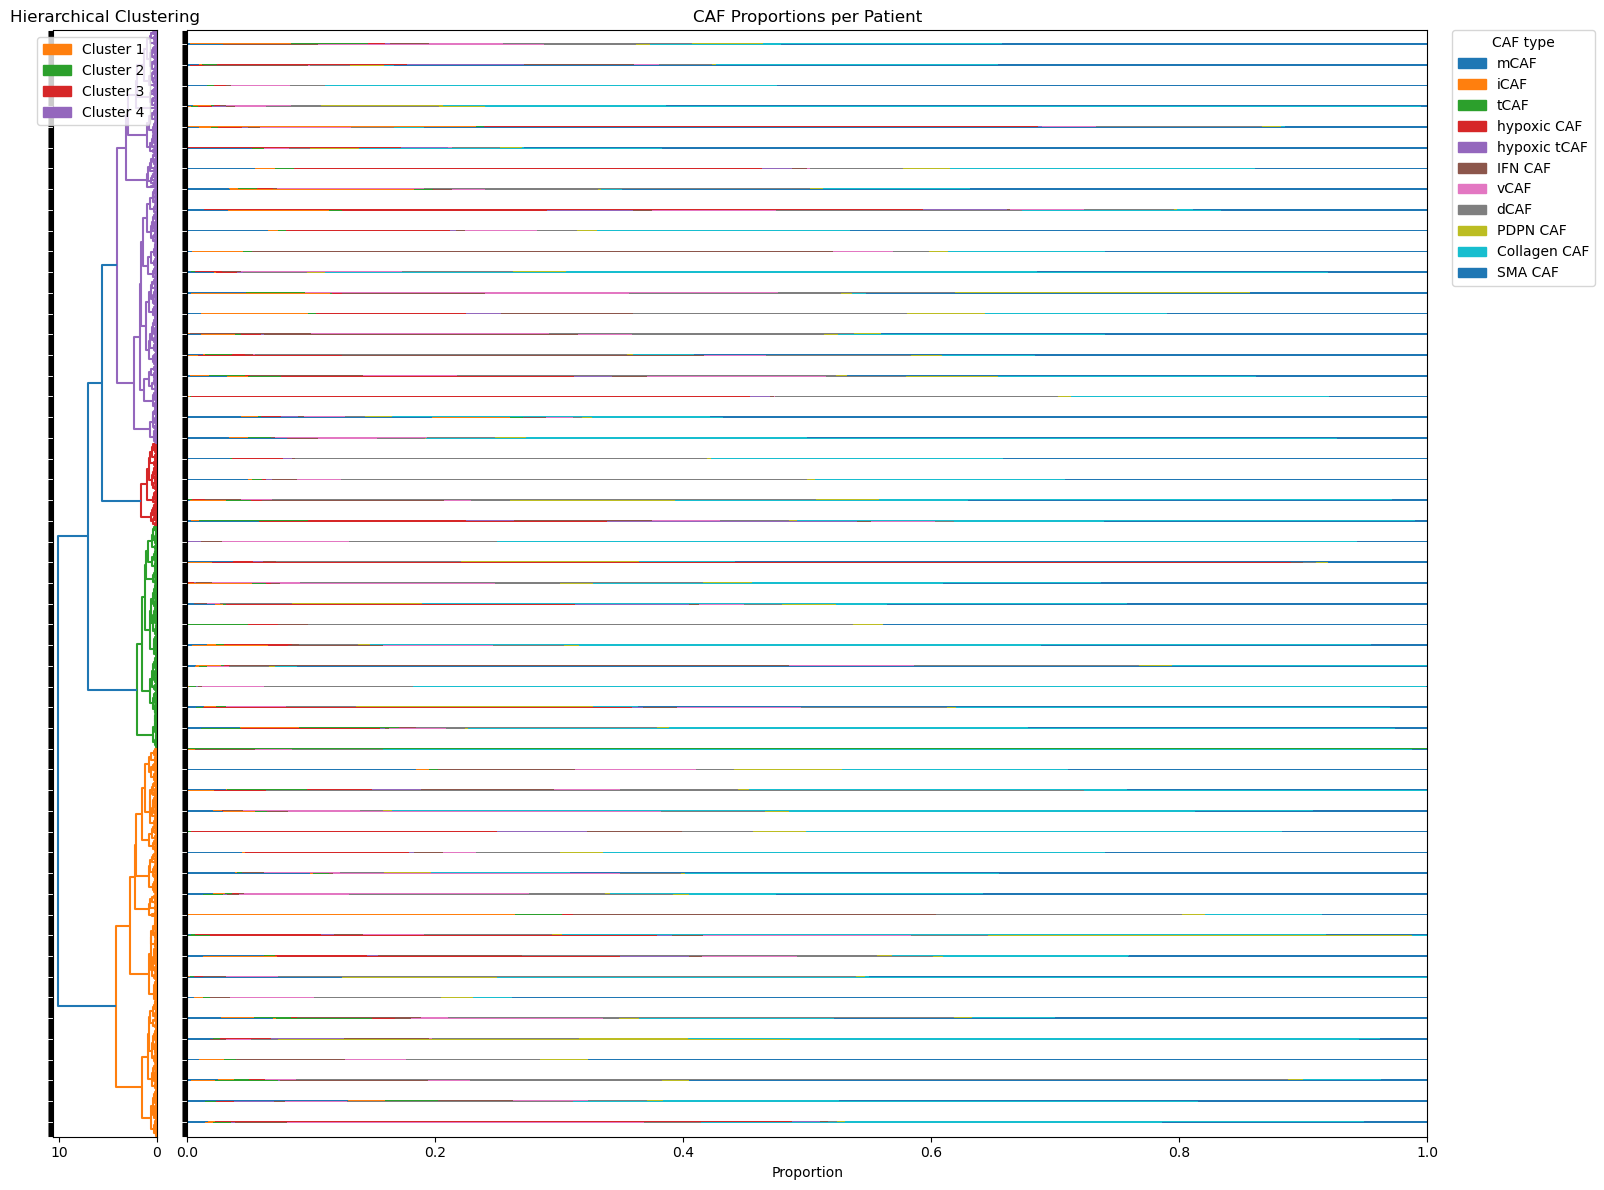

In [7]:
%matplotlib inline

# ---------------------------------------
# set up figure with two panels
# ---------------------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(16, 12),
    gridspec_kw={"width_ratios":[0.5, 6]},
    sharey=True
)

# ---------------------------------------
# dendrogram (left)
# ---------------------------------------
ddata = dendrogram(
    Z,
    orientation="left",
    color_threshold=Z[-(4-1), 2],
    no_labels=True,
    ax=axes[0]
)

# cluster assignment
clusters = fcluster(Z, t=4, criterion="maxclust")

# map cluster IDs to dendrogram leaf colors
cluster_colors = {}
for leaf_idx, leaf_color in zip(ddata['leaves'], ddata['leaves_color_list']):
    cid = clusters[leaf_idx]
    if cid not in cluster_colors:
        cluster_colors[cid] = leaf_color

# legend for dendrogram clusters
patches = [
    mpatches.Patch(color=cluster_colors[cid], label=f"Cluster {cid}")
    for cid in sorted(cluster_colors)
]
axes[0].legend(handles=patches, loc="upper right")
axes[0].set_title("Hierarchical Clustering")

# ---------------------------------------
# reorder patients by dendrogram leaf order
# ---------------------------------------
ordered_idx = [pt_caf_props_ordered.index[i] for i in ddata["leaves"]]
pt_caf_props_reordered = pt_caf_props_ordered.loc[ordered_idx]

# true y positions for leaves (matches dendrogram)
leaf_y = np.arange(len(ddata["leaves"])) * 10 + 5

# ---------------------------------------
# stacked proportions (right)
# ---------------------------------------
caf_palette = sns.color_palette("tab10", n_colors=len(caf_cols_plotting))
bottom = np.zeros(len(pt_caf_props_reordered), dtype=float)

for col, color in zip(caf_cols_plotting, caf_palette):
    axes[1].barh(
        leaf_y,
        pt_caf_props_reordered[col].values,
        left=bottom,
        color=color,
        edgecolor="none"
    )
    bottom += pt_caf_props_reordered[col].values

axes[1].set_title("CAF Proportions per Patient")
axes[1].set_xlabel("Proportion")
axes[1].set_ylabel("")

# sync y-limits with dendrogram
axes[1].set_ylim(axes[0].get_ylim())

# hide patient ID ticklabels (clean look)
axes[1].set_yticks(leaf_y)
axes[1].set_yticklabels([])

# CAF-type legend
caf_handles = [
    mpatches.Patch(color=color, label=col)
    for col, color in zip(caf_cols_plotting, caf_palette)
]
axes[1].legend(
    handles=caf_handles,
    title="CAF type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0
)

plt.tight_layout()
plt.show()

In [21]:
ordered_idx

['87_177',
 '86_67',
 '88_504',
 '176_321',
 '88_460',
 '175_84',
 '87_202',
 '88_409',
 '178_438',
 '178_395',
 '178_422',
 '88_392',
 '87_178',
 '88_513',
 '175_74',
 '175_110',
 '175_47',
 '86_55',
 '87_172',
 '88_531',
 '178_442',
 '86_57',
 '176_219',
 '88_360',
 '176_278',
 '88_471',
 '87_302',
 '88_490',
 '88_424',
 '88_533',
 '175_187',
 '175_118',
 '86_140',
 '176_282',
 '88_415',
 '175_53',
 '88_403',
 '87_185',
 '87_344',
 '86_151',
 '176_316',
 '86_65',
 '176_221',
 '88_509',
 '178_555',
 '86_44',
 '88_466',
 '87_301',
 '178_489',
 '175_139',
 '88_514',
 '86_115',
 '87_225',
 '86_138',
 '178_423',
 '87_194',
 '86_66',
 '176_301',
 '88_482',
 '87_305',
 '175_87',
 '88_367',
 '178_388',
 '175_163',
 '175_176',
 '88_440',
 '178_443',
 '178_407',
 '175_91',
 '87_183',
 '87_294',
 '87_269',
 '178_480',
 '178_391',
 '88_397',
 '176_201',
 '87_245',
 '87_231',
 '176_310',
 '88_382',
 '176_361',
 '175_173',
 '86_10',
 '178_373',
 '175_175',
 '87_292',
 '88_516',
 '87_162',
 '87_303

In [65]:
temp_pt_caf_props_reordered = pt_caf_props_reordered.head(500)
print(temp_pt_caf_props_reordered.index)
temp_pt_caf_props_reordered

Index(['87_177', '86_67', '88_504', '176_321', '88_460', '175_84', '87_202',
       '88_409', '178_438', '178_395',
       ...
       '175_57', '176_334', '86_21', '178_394', '175_106', '87_215', '178_552',
       '88_445', '87_235', '86_32'],
      dtype='object', name='pt_id', length=500)


,mCAF,iCAF,tCAF,hypoxic CAF,hypoxic tCAF,IFN CAF,vCAF,dCAF,PDPN CAF,Collagen CAF,SMA CAF
pt_id,,,,,,,,,,,
87_177,0.073171,0.000787,0.002360,0.000000,0.000000,0.001574,0.018883,0.021243,0.272227,0.398112,0.211644
86_67,0.018018,0.074646,0.011583,0.001287,0.000000,0.380952,0.027027,0.120978,0.083655,0.046332,0.235521
88_504,0.011236,0.008989,0.042697,0.008989,0.000000,0.011236,0.089888,0.053933,0.008989,0.465169,0.298876
176_321,0.032020,0.022167,0.000000,0.002463,0.000000,0.004926,0.036946,0.105911,0.012315,0.123153,0.660099
88_460,0.015564,0.000000,0.000000,0.011673,0.003891,0.000000,0.054475,0.035019,0.000000,0.696498,0.182879
...,...,...,...,...,...,...,...,...,...,...,...
87_215,0.020202,0.008979,0.004489,0.131313,0.102132,0.001122,0.005612,0.363636,0.191919,0.087542,0.083053
178_552,0.041157,0.002225,0.040044,0.020022,0.046719,0.041157,0.020022,0.045606,0.001112,0.637375,0.104561
88_445,0.090153,0.002774,0.001387,0.012483,0.000000,0.034674,0.049931,0.209431,0.008322,0.353675,0.237171


In [66]:
len(temp_pt_caf_props_reordered.index)
print(len(temp_pt_caf_props_reordered[col].values))
print(caf_cols_plotting)

500
['mCAF', 'iCAF', 'tCAF', 'hypoxic CAF', 'hypoxic tCAF', 'IFN CAF', 'vCAF', 'dCAF', 'PDPN CAF', 'Collagen CAF', 'SMA CAF']


In [ ]:
temp_props = pt_caf_props.copy()
# temp_props = pt_caf_props.head(100)

# --- Clustering patients on proportions ---
Z = linkage(temp_props, method="ward")         # hierarchical clustering
clusters = fcluster(Z, t=4, criterion="maxclust")  # assign 4 meta-clusters

# --- Reorder patients by clustering ---
dendro = dendrogram(Z, labels=temp_props.index, no_plot=True)
ordered_idx = dendro["ivl"]

print(ordered_idx)

# reorder everything
temp_props_ordered = temp_props.loc[ordered_idx]
pt_caf_counts_oredered = pt_caf_counts.loc[ordered_idx]
pt_cluster_ordered = pd.Series(clusters, index=temp_props.index).loc[ordered_idx]

# map clusters to colors
cluster_palette = {1:"red", 2:"blue", 3:"green", 4:"purple"}
cluster_colors = pd.Series(clusters, index=temp_props.index).map(cluster_palette)
cluster_colors = cluster_colors.loc[ordered_idx]
cluster_colors

['176_306', '88_443', '175_8', '178_490', '175_174', '87_301', '87_341', '87_346', '87_281', '87_314', '87_183', '176_278', '176_368', '176_219', '86_51', '175_119', '88_405', '87_316', '175_88', '87_257', '176_283', '87_176', '175_110', '87_185', '175_109', '176_235', '176_272', '87_221', '87_318', '176_249', '87_233', '176_341', '176_250', '176_342', '87_235', '86_101', '87_249', '175_12', '176_357', '87_179', '176_241', '176_304', '176_203', '87_304', '88_421', '178_467', '175_148', '175_103', '175_77', '87_299', '175_66', '176_360', '88_387', '178_553', '88_466', '87_343', '175_95', '87_275', '178_505', '176_232', '178_567', '176_207', '88_393', '87_262', '87_311', '86_142', '87_240', '176_236', '87_182', '175_108', '175_40', '88_485', '175_45', '178_483', '86_154', '88_493', '86_18', '175_79', '176_352', '88_487', '175_2', '86_158', '86_83', '88_460', '175_175', '176_367', '86_9', '87_331', '175_26', '88_494', '178_387', '178_518', '176_298', '175_39', '88_530', '176_345', '176_26

pt_id
176_306       red
88_443        red
175_8         red
178_490       red
175_174       red
            ...  
87_219     purple
175_93     purple
87_247     purple
178_521    purple
87_195     purple
Length: 1053, dtype: object

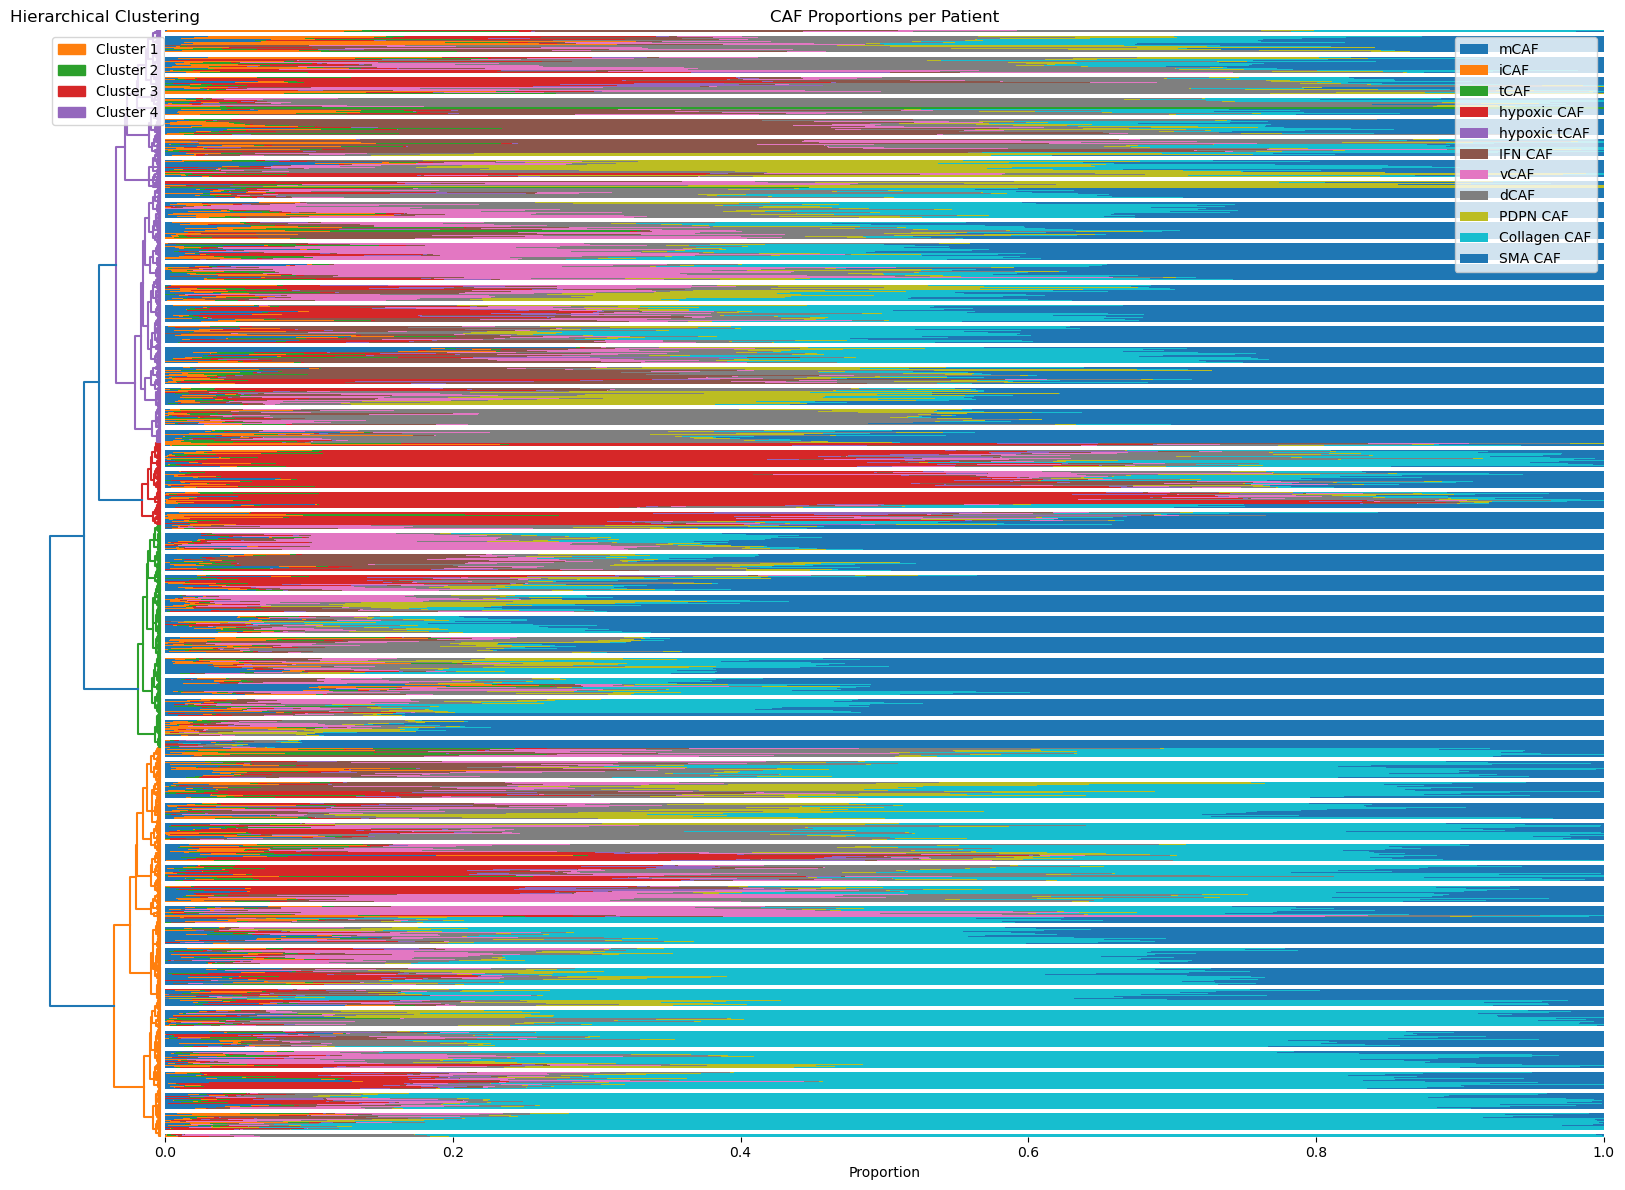

In [137]:
%matplotlib inline

fig, axes = plt.subplots(
    1, 2, figsize=(16, 12),
    gridspec_kw={"width_ratios":[0.5, 6], "wspace": 0},  # <-- wspace=0 removes gap
    sharey=True
)

# First, get the dendrogram info without plotting
ddata = dendrogram(
    Z,
    orientation="right",
    color_threshold=Z[-(4-1), 2],
    no_labels=True,
    no_plot=True
)

# Original leaf positions (spaced by 10)
orig_leaf_pos = np.array(ddata["leaves"])
orig_y = np.arange(len(orig_leaf_pos)) * 10

# Desired leaf positions (0, 1, 2, ..., n-1 to match barh)
new_y = np.arange(len(orig_leaf_pos))

# Build mapping from original y to new y
scale = (new_y.max() - new_y.min()) / (orig_y.max() - orig_y.min())
offset = new_y.min() - orig_y.min() * scale

def rescale_y(y):
    return y * scale + offset

# Rescale icoord (branch coordinates)
icoord_new = [[rescale_y(y) for y in xs] for xs in ddata["icoord"]]

# Flip the x-coordinates (dcoord) by negating and shifting
max_x = max(max(xs) for xs in ddata["dcoord"])
dcoord_flipped = [[-x + max_x for x in xs] for xs in ddata["dcoord"]]

# Plot using flipped x-coordinates
for xs, ys, color in zip(dcoord_flipped, icoord_new, ddata["color_list"]):
    axes[0].plot(xs, ys, color=color)

# map cluster IDs to dendrogram leaf colors
cluster_colors = {}
for leaf_idx, leaf_color in zip(ddata['leaves'], ddata['leaves_color_list']):
    cid = clusters[leaf_idx]
    if cid not in cluster_colors:
        cluster_colors[cid] = leaf_color

# legend for dendrogram clusters
patches = [
    mpatches.Patch(color=cluster_colors[cid], label=f"Cluster {cid}")
    for cid in sorted(cluster_colors)
]

axes[0].legend(handles=patches, loc="upper left")
axes[0].set_title("Hierarchical Clustering")


# Remove axes borders and ticks from dendrogram
axes[0].set_yticks([])
axes[0].set_yticklabels([])
axes[0].set_xticks([])
axes[0].set_xticklabels([])
axes[0].spines['top'].set_visible(False)      # <-- remove borders
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)

# Plot proportions
bottom = np.zeros(len(temp_props_ordered), dtype=float)
legend_handles = []  # <-- for legend

for col, color in zip(caf_cols_plotting, caf_palette):
    bars = axes[1].barh(
        y=temp_props_ordered.index,
        width=temp_props_ordered[col].values,
        left=bottom,
        color=color,
        edgecolor="none",
        label=col  # <-- add labels for legend
    )
    legend_handles.append(bars)  # <-- collect handles
    bottom += temp_props_ordered[col].values

axes[1].set_title("CAF Proportions per Patient")
axes[1].set_xlabel("Proportion")
axes[1].set_ylabel("")\
# Fix y-limits to match the bar positions exactly
n_samples = len(temp_props_ordered)
axes[1].set_ylim(-0.5, n_samples - 0.5)  # <-- proper bar alignment
axes[0].set_ylim(-0.5, n_samples - 0.5)  # <-- sync dendrogram

# Add legend
axes[1].legend(loc='upper right', bbox_to_anchor=(1, 1))  # <-- add legend

# Remove borders from proportions graph
axes[1].spines['top'].set_visible(False)      # <-- remove borders
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE_CSV_DIR, "caf_props_clusters.pdf"), format='pdf', dpi=300, bbox_inches='tight')
plt.show()


In [134]:
cluster_colors

{1: 'C1', 2: 'C2', 3: 'C3', 4: 'C4'}